<a href="https://colab.research.google.com/github/alaycheme25/chemeng277_batteryproject/blob/main/machine_learning_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install periodictable paretoset pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.7/830.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 950.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.3 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=66cf1c152f18d393befa17506faed4f84d9f178fc7cbba6d9f37cf17034086d3
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


### Importing necessary packages and files

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast
from sklearn.linear_model import ElasticNet

In [4]:
pdata = pd.read_excel("MATSCI_176_Project_Data.xlsx")
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,structure,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,0.003609,0.000000,3.176794,2.592432,10.0,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0,417.933696,4.179337
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,0.328351,0.000000,3.352100,3.378028,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074,1920.448911,19.204489
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,0.049545,0.000000,7.440326,2.237712,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0,735.871648,7.358716
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,0.000000,0.333634,2.592432,2.583328,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0,576.149771,5.761498
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,0.000000,0.057445,0.963259,7.527518,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0,82.574983,0.825750


In [5]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [6]:
def get_volume(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.volume
    except:
        return np.nan
# structure_volums = pdata["structure"].apply(get_volume) # Volumes in Angstrom^3
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)

In [7]:
# structure_volums = structure_volums.to_frame()
# structure_volums = structure_volums.fillna(0)
# structure_volums = structure_volums["structure"]
# pdata["structure_volume"] = structure_volums.values
pdata = pd.concat([pdata, structure_abc_df], axis=1)

In [8]:
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L,a,b,c
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,3.176794,2.592432,10.0,0.333634,0,417.933696,4.179337,5.263072,5.263072,5.263072
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,3.352100,3.378028,10.0,-0.744135,0.7074,1920.448911,19.204489,4.627959,4.627959,4.627959
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,7.440326,2.237712,10.0,-0.034716,0,735.871648,7.358716,3.649504,4.306932,4.306932
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,2.592432,2.583328,10.0,-0.330999,0,576.149771,5.761498,13.947939,13.947939,13.947939
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,0.963259,7.527518,10.0,-0.415156,0,82.574983,0.825750,3.320590,3.320590,4.319788


In [9]:
numeric_cols = [
    "material_density",
    "formation_energy_per_atom",
    "band_gap"
]

for col in numeric_cols:
    pdata[col] = pd.to_numeric(pdata[col], errors="coerce")
pdata = pdata.dropna()
pdata = pdata.reset_index(drop=True)
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L,a,b,c
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,3.176794,2.592432,10.0,0.333634,0.0000,417.933696,4.179337,5.263072,5.263072,5.263072
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,3.352100,3.378028,10.0,-0.744135,0.7074,1920.448911,19.204489,4.627959,4.627959,4.627959
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,7.440326,2.237712,10.0,-0.034716,0.0000,735.871648,7.358716,3.649504,4.306932,4.306932
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,2.592432,2.583328,10.0,-0.330999,0.0000,576.149771,5.761498,13.947939,13.947939,13.947939
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,0.963259,7.527518,10.0,-0.415156,0.0000,82.574983,0.825750,3.320590,3.320590,4.319788


In [10]:
pdata_norm = pdata.iloc[:, 6:]
print(pdata_norm.columns)

Index(['max_delta_volume', 'average_voltage', 'capacity_grav', 'capacity_vol',
       'energy_grav', 'energy_vol', 'stability_charge', 'stability_discharge',
       'electrode_density', 'material_density', 'working_ion_cost_per_kWh',
       'formation_energy_per_atom', 'band_gap', 'energy_density',
       'battery_cost_per_L', 'a', 'b', 'c'],
      dtype='object')


#### Defining our scoring function(s) to analyze and their input datasets.
We don't want to train our model on the features which are used for scoring. Therefore, we need to define a new training dataset excluding these features. Our scoring model uses gravimetric energy, gravimetric capacity, battery cost per liter, energy density, and battery voltage, so we removed these from our training data set. Additionally, features like energy volume, capacity volume, and electrode density are correlated with battery cost and energy density (as they're used in the calculations for those features), so we removed those columns from our training data to avoid any overlap.

In [11]:
# Getting the energy grav, capacity grav, battery cost per L, energy density, and average voltage columns for scoring and removing those and additional columns from the training data
energy_grav = pdata_norm["energy_grav"]
cap_grav = pdata_norm["capacity_grav"]
battery_cost = pdata_norm["battery_cost_per_L"]
energy_density = pdata_norm["energy_density"]
voltage = pdata_norm['average_voltage']
# training_data = pdata_norm.drop(columns=["energy_grav", "capacity_grav", "battery_cost_per_L", "energy_density", "average_voltage", "energy_vol", "capacity_vol", "electrode_density", "max_delta_volume", "stability_discharge"])
training_data = pdata_norm.drop(columns=["energy_grav", "battery_cost_per_L", "energy_density", "electrode_density", "stability_charge", "energy_vol", "capacity_vol"])
# training_data["average_voltage"] = np.abs(training_data["average_voltage"])
# Creating a new training dataset without cost to benchmark our scoring with and without cost, since our cost is not from the same source (Materials Project)
training_data_nocost = training_data.drop(columns=["working_ion_cost_per_kWh"])


In [12]:
training_data_nocost.head()
# print(training_data.columns)

,max_delta_volume,average_voltage,capacity_grav,stability_discharge,material_density,formation_energy_per_atom,band_gap,a,b,c
0,2.736089,0.210565,624.785871,0.000000,2.592432,0.333634,0.0000,5.263072,5.263072,5.263072
1,1.569237,1.015953,563.913254,0.000000,3.378028,-0.744135,0.7074,4.627959,4.627959,4.627959
2,0.368255,0.796796,124.126099,0.000000,2.237712,-0.034716,0.0000,3.649504,4.306932,4.306932
3,2.951183,-0.444846,499.595769,0.333634,2.583328,-0.330999,0.0000,13.947939,13.947939,13.947939
4,1.513956,-0.064931,1320.248328,0.057445,7.527518,-0.415156,0.0000,3.320590,3.320590,4.319788


In [13]:
def scoring_nocost(e_g):
    e_g = e_g.to_numpy().astype(float)
    # c_g = c_g.to_numpy().astype(float)
    # e_d = e_d.to_numpy().astype(float)
    # v = v.to_numpy().astype(float)
    # Centralize the score and normalize it to be between 0 and 1, with the highest score being the best
    # score = np.abs(e_d)/np.max(e_d) + np.abs(c_g)/np.max(c_g) + np.abs(v)/np.max(v)
    score = (e_g)
    return pd.Series(score)

def scoring_withcost(c_g,b_c,e_d,v):
    c_g = c_g.to_numpy().astype(float)
    b_c = b_c.to_numpy().astype(float)
    e_d = e_d.to_numpy().astype(float)
    v = v.to_numpy().astype(float)
    score = np.abs(e_d)/np.max(e_d) + np.abs(c_g/b_c)/(np.max(c_g)/np.max(b_c)) + np.abs(v)/np.max(v)
    return pd.Series(score)

### Benchmarking the Ridge & Elastic Net Regressional Models
We chose ridge regression and elasticnet regression to both identify important features (from the ridge component) while zeroing out features which don't affect battery performance (features that don't affect our score.)

In [14]:
# Testing the no-cst scoring function and defining our fit & training datasets.
# battery_score = scoring_nocost(cap_grav, energy_density, voltage)
battery_score = scoring_nocost(energy_grav)

fit_train, fit_test, score_train, score_test = train_test_split(
    training_data_nocost,
    battery_score,
    test_size=0.1,
    random_state=42
)

# Normalization of the fit and training datasets for better performance of the elastic net model, since it is sensitive to the scale of the features
norm_fit_train = pd.DataFrame(
    StandardScaler().fit_transform(fit_train),
    columns=fit_train.columns
)
norm_fit_test = pd.DataFrame(
    StandardScaler().fit_transform(fit_test),
    columns=fit_test.columns
)

In [15]:
ridge = linear_model.Ridge(alpha=3.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(f"Effective R^2 score: {score_pred:.3f}")

Effective R^2 score: 0.605


In [16]:
best = np.where(battery_score == np.max(battery_score))[0][0]
# print(pdata_norm.iloc[best])
print(pdata.iloc[best])
# print(len(pdata["capacity_grav"]))
# print(len(pdata_norm["capacity_grav"]))
print("Battery Score:", np.max(battery_score))
# print(energy_grav.iloc[best], cap_grav.iloc[best], energy_density.iloc[best], voltage.iloc[best])

battery_formula                 Li0-3ClO
working_ion                           Li
elements                     ['Cl', 'O']
nelements                            2.0
formula_charge                       ClO
formula_discharge                 Li3ClO
max_delta_volume                1.020934
average_voltage                 4.299346
capacity_grav                1112.473171
capacity_vol                 2236.418805
energy_grav                  4782.906878
energy_vol                   9615.137841
stability_charge                1.553271
stability_discharge             0.027568
electrode_density               2.010313
material_density                3.455668
working_ion_cost_per_kWh            10.0
formation_energy_per_atom      -0.151988
band_gap                             0.0
energy_density               9615.137841
battery_cost_per_L             96.151378
a                               4.677535
b                               4.677535
c                               4.677535
Name: 4014, dtyp



## Performing K-folds cross validation on our ridge regressional model.
Choosing k-folds is important to determine if our train-validation split was truely indicative of the full system.

In [17]:
X = training_data_nocost
y = battery_score
y = y.fillna(0)
y = y.astype(float)

In [26]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=3.0)) # We chose alpha = 5.0 to weight against sparsity in our features.
])

In [27]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_ridge = []
params = []
best_ridge_score = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)
    params.append(ridge_pipeline.named_steps["ridge"].coef_)

    #Find best material in predicted set
    bestmaterial_ridge.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])
    best_ridge_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
bestmaterial_df_ridge = pd.DataFrame(bestmaterial_ridge)
# bestmaterial_df
# print(params)

Mean R2: 0.5744574919924883
Mean MSE: 47714.419003927374
Mean MAE: 134.59390621899547


In [28]:
# Converting the best material features back to the original scale for comparison with the original dataset, since we normalized the training & test data.
# To do so, we took the best material from each fold and compared their features to the original datasets to find the approximated battery  (the battery formula with the smallest minimum difference between predicted best and the rest of the dataset).
for i in range(len(bestmaterial_df_ridge)):
    best_material = bestmaterial_df_ridge.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Ca0-2N2
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Mg5-149Ag
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Li0-3ClO


## Testing Elastic Net Regression in the same way as Ridge Regression

In [122]:
alpha = 20
l1_ratio = 0.5  # 0=ridge-like, 1=lasso-like

enet_pipeline = Pipeline([
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

score_pred_enet = enet_pipeline.fit(fit_train, score_train).score(fit_test, score_test)
print("ElasticNet test R^2:", score_pred_enet)

ElasticNet test R^2: 0.32454927866268457


In [124]:
#replace Ridge KFold with Elastic Net KFold

X = training_data_nocost
y = battery_score.fillna(0).astype(float)

# Elastic Net hyperparameters
alpha = 20
l1_ratio = 0.5

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_elastic = []
best_elastic_score = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    enet_pipeline.fit(X_train, y_train)
    y_pred = enet_pipeline.predict(X_test)

    # store best predicted sample in this fold (same idea as your ridge code)
    bestmaterial_elastic.append(X_test.iloc[np.argmax(y_pred)])
    best_elastic_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R^2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))

bestmaterial_df_elastic = pd.DataFrame(bestmaterial_elastic)
bestmaterial_df_elastic

Mean R^2: 0.08965316358800467
Mean MSE: 102473.52684170613
Mean MAE: 235.9493198113154


,max_delta_volume,average_voltage,capacity_grav,stability_discharge,material_density,formation_energy_per_atom,band_gap,a,b,c
4532,0.005618,6.078897,70.204678,0.000000,3.137850,-2.501663,3.0572,8.462882,8.642456,8.763207
233,2.670845,10.529148,418.123744,0.764373,1.756927,-0.032036,0.0000,6.811356,6.811356,5.315928
3161,0.049228,16.123656,37.137243,0.146989,3.322692,-2.569354,2.1465,7.922504,7.327339,9.582478
3204,0.086321,33.065771,133.516371,0.074915,5.482777,-2.067682,0.0000,5.855278,5.856461,5.911422
4722,0.011352,7.055537,166.877457,0.069818,3.069224,-2.477403,3.7823,6.503772,10.571203,17.601367
3692,0.033980,9.739166,35.805815,0.044644,3.073730,-2.276049,0.0135,5.133043,5.104876,5.133371
2381,0.059184,14.246550,40.858352,0.000000,2.404384,-2.147097,2.7054,9.739110,8.421082,10.972312
526,0.056833,7.505595,140.336902,0.037030,8.578987,-2.012580,1.0617,5.573317,5.573317,10.512927
3983,0.011422,7.824564,153.211905,0.052869,5.295698,-0.594838,0.0000,5.966318,6.249012,7.927109
4061,0.220730,9.322973,144.177705,0.027011,3.292507,-1.806412,0.1591,5.111480,10.391440,17.521614


In [58]:
for i in range(len(bestmaterial_elastic)):
    best_material_temp = bestmaterial_df_elastic.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material_temp - pdata.iloc[j, 6:6+len(best_material_temp)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Ca0-2N2
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Mg7-149Cr
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Li0-3ClO


### Plotting the elastic net best battery scores vs ridge best battery scores

<function matplotlib.pyplot.show(close=None, block=None)>

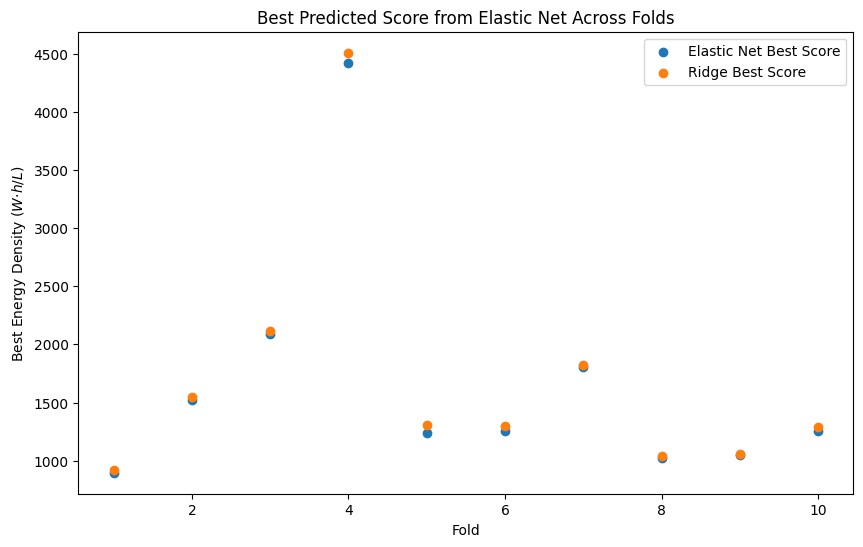

In [59]:
# Plot the best scores from ridge and elastic net for comparison
plt.figure(figsize=(10, 6))
plt.scatter(range(1, 11), best_elastic_score, marker='o', label='Elastic Net Best Score')
plt.scatter(range(1, 11), best_ridge_score, marker='o', label='Ridge Best Score')
plt.xlabel('Fold')
plt.ylabel(r'Best Energy Density $(W⋅h/L)$')
plt.legend()
plt.title('Best Predicted Score from Elastic Net Across Folds')
plt.show


## Testing on other DFT-based features from materials project:
Testing to see if our model & scoring function can predict the quality of a battery based on untrained features, which still correlate with battery lifetime and hence the score.

In [33]:
test_data = pd.read_csv("mp_battery_test_data.csv")
test_data.head()

,Unnamed: 0,working_ion,average_voltage,capacity_grav,energy_grav,max_delta_volume,formula_pretty,density,structure,formation_energy_per_atom,energy_above_hull,band_gap
0,0,Mg,-0.175966,781.306652,-137.483461,0.360047,CsMg3,2.203340,"{'@module': 'pymatgen.core.structure', '@class...",0.276177,0.276177,0.0
1,1,Rb,-0.019232,206.531251,-3.972079,2.388242,CsRb3,1.600529,"{'@module': 'pymatgen.core.structure', '@class...",0.027286,0.027286,0.0
2,2,K,-0.032541,321.360236,-10.457389,1.907409,CsK3,1.192071,"{'@module': 'pymatgen.core.structure', '@class...",0.018994,0.018994,0.0
3,3,Y,-0.465008,362.490310,-168.560829,0.187048,CsY,3.833530,"{'@module': 'pymatgen.core.structure', '@class...",0.716882,0.716882,0.0
4,4,Rb,-0.043412,206.531251,-8.965891,2.403271,CsRb3,1.590429,"{'@module': 'pymatgen.core.structure', '@class...",0.045421,0.045421,0.0


In [34]:
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)
test_data.head()

,Unnamed: 0,working_ion,average_voltage,capacity_grav,energy_grav,max_delta_volume,formula_pretty,density,structure,formation_energy_per_atom,energy_above_hull,band_gap
0,0,Mg,-0.175966,781.306652,-137.483461,0.360047,CsMg3,2.203340,"{'@module': 'pymatgen.core.structure', '@class...",0.276177,0.276177,0.0
1,1,Rb,-0.019232,206.531251,-3.972079,2.388242,CsRb3,1.600529,"{'@module': 'pymatgen.core.structure', '@class...",0.027286,0.027286,0.0
2,2,K,-0.032541,321.360236,-10.457389,1.907409,CsK3,1.192071,"{'@module': 'pymatgen.core.structure', '@class...",0.018994,0.018994,0.0
3,3,Y,-0.465008,362.490310,-168.560829,0.187048,CsY,3.833530,"{'@module': 'pymatgen.core.structure', '@class...",0.716882,0.716882,0.0
4,4,Rb,-0.043412,206.531251,-8.965891,2.403271,CsRb3,1.590429,"{'@module': 'pymatgen.core.structure', '@class...",0.045421,0.045421,0.0


In [35]:
structures = test_data["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(4829,)
Full Formula (Cs1 Rb3)
Reduced Formula: CsRb3
abc   :   7.391966   7.391966   7.391965
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (4)
  #  SP       a     b     c    magmom
---  ----  ----  ----  ----  --------
  0  Cs    -0    -0    -0          -0
  1  Rb    -0     0.5   0.5        -0
  2  Rb     0.5  -0     0.5        -0
  3  Rb     0.5   0.5  -0          -0
(7.39196596, 7.39196596, 7.39196487)
403.90554074810285


In [36]:
structure_abc = test_data["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
test_data = test_data.drop(columns=["structure"], axis=1)

In [37]:
test_data = pd.concat([test_data, structure_abc_df], axis=1)

In [38]:
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)
test_data.head()

,Unnamed: 0,working_ion,average_voltage,capacity_grav,energy_grav,max_delta_volume,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,a,b,c
0,0,Mg,-0.175966,781.306652,-137.483461,0.360047,CsMg3,2.203340,0.276177,0.276177,0.0,3.752604,4.900757,8.434517
1,1,Rb,-0.019232,206.531251,-3.972079,2.388242,CsRb3,1.600529,0.027286,0.027286,0.0,7.391966,7.391966,7.391965
2,2,K,-0.032541,321.360236,-10.457389,1.907409,CsK3,1.192071,0.018994,0.018994,0.0,8.635094,8.635094,8.635094
3,3,Y,-0.465008,362.490310,-168.560829,0.187048,CsY,3.833530,0.716882,0.716882,0.0,3.843415,3.843415,7.510495
4,4,Rb,-0.043412,206.531251,-8.965891,2.403271,CsRb3,1.590429,0.045421,0.045421,0.0,9.078593,9.078593,9.078593


In [39]:
test_data.head()

,Unnamed: 0,working_ion,average_voltage,capacity_grav,energy_grav,max_delta_volume,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,a,b,c
0,0,Mg,-0.175966,781.306652,-137.483461,0.360047,CsMg3,2.203340,0.276177,0.276177,0.0,3.752604,4.900757,8.434517
1,1,Rb,-0.019232,206.531251,-3.972079,2.388242,CsRb3,1.600529,0.027286,0.027286,0.0,7.391966,7.391966,7.391965
2,2,K,-0.032541,321.360236,-10.457389,1.907409,CsK3,1.192071,0.018994,0.018994,0.0,8.635094,8.635094,8.635094
3,3,Y,-0.465008,362.490310,-168.560829,0.187048,CsY,3.833530,0.716882,0.716882,0.0,3.843415,3.843415,7.510495
4,4,Rb,-0.043412,206.531251,-8.965891,2.403271,CsRb3,1.590429,0.045421,0.045421,0.0,9.078593,9.078593,9.078593


In [40]:
stability_discharge = test_data["energy_above_hull"]
material_density = test_data["density"]
formation_energy_per_atom = test_data["formation_energy_per_atom"]
band_gap = test_data["band_gap"]
a = test_data["a"]
b = test_data["b"]
c = test_data["c"]
capacity_grav = test_data["capacity_grav"]
energy_grav = test_data["energy_grav"]
formula_pretty = test_data["formula_pretty"]
max_delta_volume = test_data["max_delta_volume"]
voltage = test_data["average_voltage"]
test_data_short = pd.DataFrame({
    "formula_pretty": formula_pretty,
    "max_delta_volume": max_delta_volume,
    "average_voltage": voltage,
    "capacity_grav": capacity_grav,
    "stability_discharge": stability_discharge,
    "material_density": material_density,
    "formation_energy_per_atom": formation_energy_per_atom,
    "band_gap": band_gap,
    "a": a,
    "b": b,
    "c": c,
})

In [41]:
test_data_short.head()

,formula_pretty,max_delta_volume,average_voltage,capacity_grav,stability_discharge,material_density,formation_energy_per_atom,band_gap,a,b,c
0,CsMg3,0.360047,-0.175966,781.306652,0.276177,2.203340,0.276177,0.0,3.752604,4.900757,8.434517
1,CsRb3,2.388242,-0.019232,206.531251,0.027286,1.600529,0.027286,0.0,7.391966,7.391966,7.391965
2,CsK3,1.907409,-0.032541,321.360236,0.018994,1.192071,0.018994,0.0,8.635094,8.635094,8.635094
3,CsY,0.187048,-0.465008,362.490310,0.716882,3.833530,0.716882,0.0,3.843415,3.843415,7.510495
4,CsRb3,2.403271,-0.043412,206.531251,0.045421,1.590429,0.045421,0.0,9.078593,9.078593,9.078593


In [42]:
test_data_feature = test_data_short.drop(columns=["formula_pretty"])
test_data_score = energy_grav

In [43]:
norm_test_data = pd.DataFrame(
    StandardScaler().fit_transform(test_data_feature),
    columns=test_data_feature.columns
)

In [44]:
test_pred = ridge_pipeline.predict(test_data_feature)

In [45]:
r2_score((test_data_score), test_pred)

-0.6959970769645341

In [46]:
test_pred


array([432.58274941, -25.95173935,  45.64813753, ...,  27.38496164,
       102.47076307, 282.51228486])

In [48]:
ridge.coef_

array([ -7.63694877, 135.2069768 ,   0.68929941,   8.73579898,
         4.97622085, -20.76804793,  -2.55048805,  -5.73839607,
        -4.22910976,  -1.53492237])

In [125]:
test_pred = enet_pipeline.predict(test_data_feature)

In [126]:
r2_score((test_data_score), test_pred)

-0.19524094884896392

In [127]:
test_pred

array([353.54604985, 338.58314823, 342.42572658, ..., 330.7399858 ,
       336.00021341, 355.62735382])

In [128]:
ridge_pipeline.named_steps["ridge"].coef_

array([-51.48122458, 242.95755376, 120.26855015,   5.2176143 ,
         5.70470471, -13.88626994,  -2.82331641, -15.51550515,
        -8.11775617,  -5.797324  ])

In [121]:
enet_pipeline.named_steps["enet"].coef_

array([-16.74709447, 220.12469633,  80.9939174 ,  -0.        ,
         0.        ,  -0.        ,  -0.        ,  -0.        ,
        -0.        ,  -0.        ])

In [ ]:
X = training_data_nocost
y = battery_score.fillna(0).astype(float)

# Elastic Net hyperparameters
alpha = 3
l1_ratio = 0.5

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_elastic = []
best_elastic_score = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    enet_pipeline.fit(X_train, y_train)
    y_pred = enet_pipeline.predict(X_test)

    # store best predicted sample in this fold (same idea as your ridge code)
    bestmaterial_elastic.append(X_test.iloc[np.argmax(y_pred)])
    best_elastic_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R^2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))

bestmaterial_df_elastic = pd.DataFrame(bestmaterial_elastic)
bestmaterial_df_elastic